## MVTec AD + Vision Transformer: 제품 이미지 불량 분류 PoC

**MVTec AD**(산업용 이상 탐지 벤치마크)와 HuggingFace **ViT** 사전학습 모델로
제품 이미지의 **시각 표현(임베딩)** 을 학습·활용하고, **Cosine Similarity** 기반으로
정상/불량을 구분하는 **Proof of Concept** 예제입니다.

| 섹션 | 내용 |
|------|------|
| MVTec AD | HuggingFace에서 capsule 카테고리 로드 (Colab 자동 다운로드) |
| Image Embedding | ViT hidden state → CLS / Mean Pooling → L2 정규화 |
| Similarity 분석 | 정상 프로토타입 대비 Cosine Similarity, 유사도 행렬 시각화 |
| 불량 분류 PoC | (1) 정상 프로토타입 이상 점수 (2) k-NN 임베딩 분류기 |

**MVTec AD 구조 (표준)**
- `train`: 결함 없는 정상 이미지만
- `test`: 정상 + 다양한 결함 유형

> **실행 환경**: Google Colab (GPU 권장) 또는 로컬 Jupyter  
> **데이터**: `alexsu52/mvtec_capsule` (약 400MB, 라벨: normal / abnormal)  
> **모델**: `google/vit-base-patch16-224` (ImageNet 사전학습)

<br>
PoC(Proof of Concept): 이 기술이나 아이디어가 실제로 가능한지 먼저 검증해 보는 작은 규모의 실험

### 1. 환경 설정 및 패키지 설치

In [1]:
# ========== 실행 환경 감지 ==========
try:
    import google.colab
    IN_COLAB = True
    print('Google Colab 환경에서 실행 중')
except ImportError:
    IN_COLAB = False
    print('로컬 Jupyter 환경에서 실행 중')

로컬 Jupyter 환경에서 실행 중


In [2]:
# ========== 패키지 설치 (최초 1회) ==========
# if IN_COLAB:
#     %pip install -q transformers datasets scikit-learn seaborn

# 로컬 터미널 예시:
# py -3.11 -m pip install transformers datasets scikit-learn pillow matplotlib seaborn

In [3]:
# ========== 라이브러리 import ==========
import io
import logging
from pathlib import Path
from typing import Literal

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F
import tarfile

from datasets import ClassLabel, Dataset, Features
from datasets import Image as HFImage
from huggingface_hub import hf_hub_download
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from transformers import AutoImageProcessor, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')


def setup_korean_font() -> str:
    available = {font.name for font in fm.fontManager.ttflist}
    for name in [
        'Malgun Gothic', 'AppleGothic', 'NanumGothic',
        'NanumBarunGothic', 'Noto Sans CJK KR', 'Noto Sans KR',
    ]:
        if name in available:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False
            return name
    plt.rcParams['axes.unicode_minus'] = False
    return 'DejaVu Sans'


logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
print(f'matplotlib 한글 폰트: {setup_korean_font()}')

RNG = np.random.default_rng(42)
torch.manual_seed(42)

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


사용 디바이스: cuda
matplotlib 한글 폰트: Malgun Gothic


### 2. MVTec AD 데이터셋 로드 (Capsule)

[MVTec AD](https://www.mvtec.com/company/research/datasets/mvtec-ad)의 **capsule**(캡슐) 카테고리를
HuggingFace `alexsu52/mvtec_capsule` 에서 불러옵니다.

- `train` 219장: 학습용 **정상** 이미지
- `test` 132장: 정상 + **불량(abnormal)** 혼합
- 라벨: `0=normal`, `1=abnormal`

In [4]:
# ========== MVTec AD (capsule) 로드 ==========
# datasets>=4: Hub 로딩 스크립트(mvtec_capsule.py) 미지원 → archive 직접 다운로드
MVTEC_HF_ID = 'alexsu52/mvtec_capsule'
MVTEC_ARCHIVE = 'capsule.tar.xz'
LABEL_NAMES = {0: 'normal', 1: 'abnormal'}


def load_mvtec_capsule(repo_id: str = MVTEC_HF_ID) -> dict[str, Dataset]:
    """alexsu52/mvtec_capsule — datasets 4.x 호환 로더 (원본 스크립트와 동일 분할)."""
    archive_path = hf_hub_download(
        repo_id=repo_id,
        repo_type='dataset',
        filename=MVTEC_ARCHIVE,
    )
    extract_dir = Path(archive_path).parent / 'mvtec_capsule_extracted'
    category_dir = extract_dir / 'capsule'
    if not category_dir.is_dir():
        extract_dir.mkdir(parents=True, exist_ok=True)
        with tarfile.open(archive_path, 'r:xz') as tar:
            tar.extractall(extract_dir)

    def _split_records(split_name: str) -> list[dict]:
        records: list[dict] = []
        masks: list[str] = []
        for image_file in category_dir.rglob('*.png'):
            rel = image_file.relative_to(category_dir)
            if len(rel.parts) != 3:
                continue
            spl, defect_label, _ = rel.parts
            if spl == 'ground_truth':
                masks.append(str(image_file))
                continue
            records.append({
                'split': spl,
                'image': str(image_file),
                'label': 0 if defect_label == 'good' else 1,
            })

        masks.sort()
        abnormal_test = sorted(
            (r for r in records if r['split'] == 'test' and r['label'] == 1),
            key=lambda r: r['image'],
        )
        if len(abnormal_test) != len(masks):
            raise RuntimeError('이상 이미지와 ground_truth 마스크 개수가 일치하지 않습니다.')
        for rec, mask_path in zip(abnormal_test, masks):
            if Path(rec['image']).stem not in Path(mask_path).stem:
                raise RuntimeError(f'마스크 매칭 오류: {rec["image"]} ↔ {mask_path}')

        return [
            {'image': r['image'], 'label': r['label']}
            for r in records
            if r['split'] == split_name
        ]

    features = Features({
        'image': HFImage(),
        'label': ClassLabel(names=['normal', 'abnormal']),
    })
    return {
        'train': Dataset.from_list(_split_records('train'), features=features),
        'test': Dataset.from_list(_split_records('test'), features=features),
    }


ds = load_mvtec_capsule(MVTEC_HF_ID)
train_ds = ds['train']
test_ds = ds['test']

print(f'데이터셋: {MVTEC_HF_ID} (archive 직접 로드)')
print(f'  train: {len(train_ds)}장')
print(f'  test:  {len(test_ds)}장')

# test 라벨 분포
test_labels = np.array(test_ds['label'])
for lbl in [0, 1]:
    cnt = (test_labels == lbl).sum()
    print(f'  test {LABEL_NAMES[lbl]}: {cnt}장')

데이터셋: alexsu52/mvtec_capsule (archive 직접 로드)
  train: 219장
  test:  132장
  test normal: 23장
  test abnormal: 109장


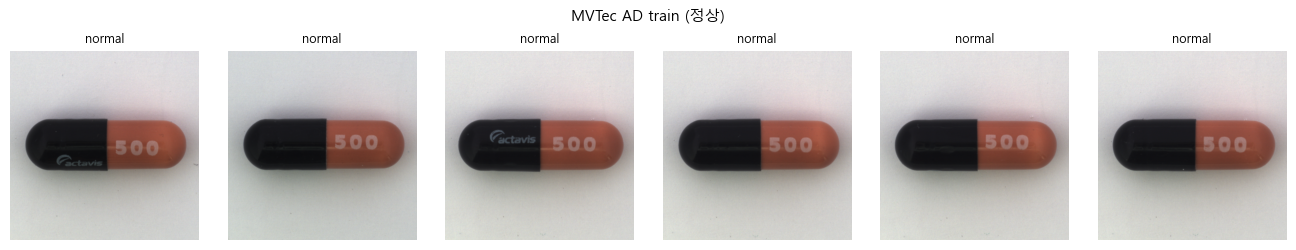

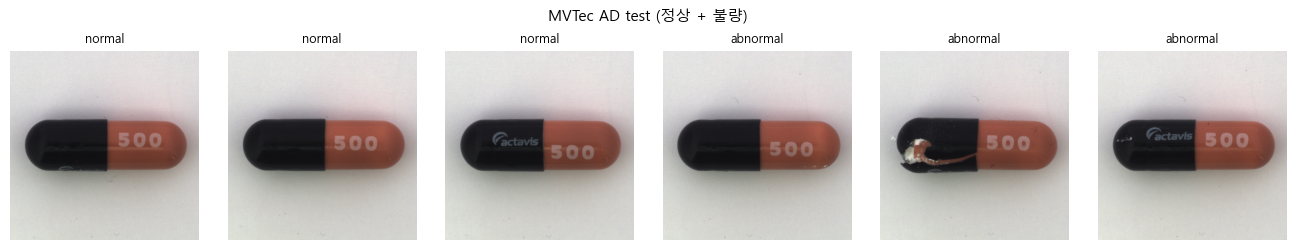

In [5]:
# ========== 샘플 이미지 시각화 ==========
def hf_row_to_pil(row) -> Image.Image:
    """HuggingFace row → RGB PIL Image."""
    img = row['image']
    if isinstance(img, Image.Image):
        return img.convert('RGB')
    return Image.fromarray(np.asarray(img)).convert('RGB')


def show_mvtec_grid(rows, title: str, ncols: int = 6):
    n = min(len(rows), ncols)
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.5))
    if n == 1:
        axes = [axes]
    for ax, row in zip(axes, rows[:n]):
        ax.imshow(hf_row_to_pil(row))
        lbl = row.get('label', None)
        name = LABEL_NAMES.get(lbl, 'train') if lbl is not None else 'train'
        ax.set_title(name, fontsize=9)
        ax.axis('off')
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


show_mvtec_grid([train_ds[i] for i in range(6)], 'MVTec AD train (정상)')

abnormal_idx = [i for i in range(len(test_ds)) if test_ds[i]['label'] == 1][:3]
normal_idx = [i for i in range(len(test_ds)) if test_ds[i]['label'] == 0][:3]
show_mvtec_grid([test_ds[i] for i in normal_idx + abnormal_idx], 'MVTec AD test (정상 + 불량)')

### 3. HuggingFace ViT 모델 로드

`google/vit-base-patch16-224` — 입력 224×224, 출력 `last_hidden_state` shape `[batch, 197, 768]`  
(197 = 1 CLS + 196 패치)

In [6]:
# ========== ViT 모델 및 전처리기 ==========
MODEL_NAME = 'google/vit-base-patch16-224'
BATCH_SIZE = 16

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

HIDDEN_DIM = model.config.hidden_size
print(f'모델: {MODEL_NAME}')
print(f'Hidden dim: {HIDDEN_DIM}')

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 3672.51it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델: google/vit-base-patch16-224
Hidden dim: 768


### 4. Image Embedding: Pooling 구현

| Pooling | 설명 |
|---------|------|
| **CLS** | `[CLS]` 토큰(인덱스 0) — ViT 분류 헤드와 동일 |
| **Mean** | 패치 토큰(1~) 평균 — 공간 정보를 평균 반영 |

Cosine Similarity 사용 시 **L2 정규화**를 적용합니다.

In [7]:
# ========== Pooling 및 배치 인코딩 ==========
PoolingStrategy = Literal['cls', 'mean']


def pool_hidden_state(
    hidden_state: torch.Tensor,
    strategy: PoolingStrategy = 'cls',
) -> torch.Tensor:
    """[batch, seq_len, hidden_dim] → [batch, hidden_dim]"""
    if strategy == 'cls':
        return hidden_state[:, 0, :]
    if strategy == 'mean':
        return hidden_state[:, 1:, :].mean(dim=1)
    raise ValueError(f'지원하지 않는 pooling: {strategy}')


@torch.no_grad()
def encode_pil_batch(
    images: list[Image.Image],
    strategy: PoolingStrategy = 'cls',
    normalize: bool = True,
) -> torch.Tensor:
    inputs = processor(images=images, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    emb = pool_hidden_state(outputs.last_hidden_state, strategy=strategy)
    if normalize:
        emb = F.normalize(emb, p=2, dim=-1)
    return emb.cpu()


def encode_hf_split(
    split,
    strategy: PoolingStrategy = 'cls',
    batch_size: int = BATCH_SIZE,
    max_samples: int | None = None,
) -> tuple[torch.Tensor, np.ndarray]:
    """HuggingFace split 전체 → (embeddings [N,D], labels [N])."""
    n = len(split) if max_samples is None else min(len(split), max_samples)
    all_emb: list[torch.Tensor] = []
    labels: list[int] = []

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_imgs = [hf_row_to_pil(split[i]) for i in range(start, end)]
        all_emb.append(encode_pil_batch(batch_imgs, strategy=strategy))
        if 'label' in split.features:
            labels.extend(int(split[i]['label']) for i in range(start, end))
        else:
            labels.extend([0] * (end - start))  # train = 정상

    return torch.cat(all_emb, dim=0), np.array(labels, dtype=np.int64)

### 5. Train / Test 임베딩 생성

In [8]:
# ========== 전체 split 임베딩 (CLS pooling) ==========
POOLING: PoolingStrategy = 'cls'

print('train 임베딩 추출 중...')
emb_train, y_train = encode_hf_split(train_ds, strategy=POOLING)
print('test 임베딩 추출 중...')
emb_test, y_test = encode_hf_split(test_ds, strategy=POOLING)

print(f'emb_train: {tuple(emb_train.shape)}')
print(f'emb_test:  {tuple(emb_test.shape)}')

train 임베딩 추출 중...
test 임베딩 추출 중...
emb_train: (219, 768)
emb_test:  (132, 768)


### 6. Cosine Similarity 분석

L2 정규화된 벡터 $a, b$ 에 대해:

$$\text{cosine\_sim}(a, b) = a \cdot b \quad (\|a\|=\|b\|=1)$$

정상 train의 **프로토타입(평균 임베딩)** 과 test 이미지 간 유사도를 계산하면,
불량 이미지는 일반적으로 유사도가 **낮게** 나타납니다.

In [9]:
# ========== Cosine Similarity 유틸 ==========
def cosine_similarity_matrix(embeddings: torch.Tensor) -> torch.Tensor:
    """[N, D] L2 정규화 임베딩 → [N, N] 유사도 행렬."""
    return embeddings @ embeddings.T


def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item())


# 정상 프로토타입: train 임베딩 평균 후 L2 정규화
normal_prototype = F.normalize(emb_train.mean(dim=0, keepdim=True), p=2, dim=-1)[0]
sim_to_normal = (emb_test @ normal_prototype).numpy()

print(f'정상 프로토타입 ↔ test Cosine Sim — mean: {sim_to_normal.mean():.4f}')
for lbl in [0, 1]:
    mask = y_test == lbl
    print(f'  {LABEL_NAMES[lbl]:8s}: {sim_to_normal[mask].mean():.4f}')

정상 프로토타입 ↔ test Cosine Sim — mean: 0.9516
  normal  : 0.9712
  abnormal: 0.9475


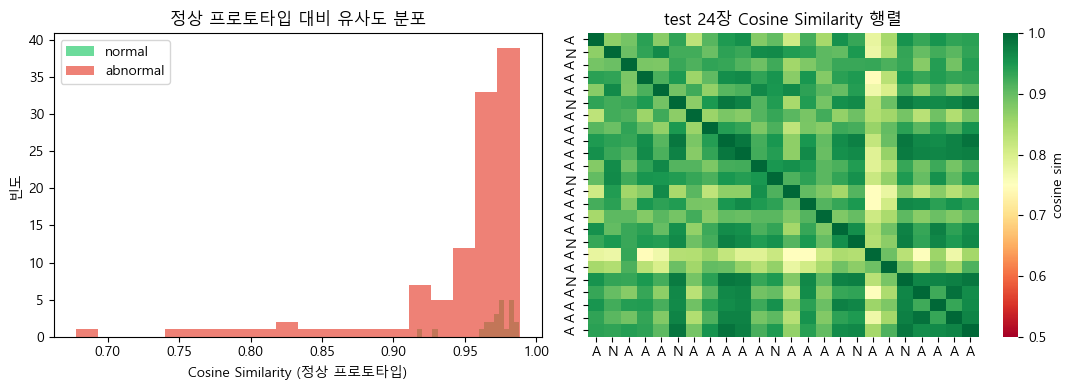

In [10]:
# ========== 유사도 분포 및 소규모 행렬 히트맵 ==========
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sim_to_normal[y_test == 0], bins=20, alpha=0.7, label='normal', color='#2ecc71')
axes[0].hist(sim_to_normal[y_test == 1], bins=20, alpha=0.7, label='abnormal', color='#e74c3c')
axes[0].set_xlabel('Cosine Similarity (정상 프로토타입)')
axes[0].set_ylabel('빈도')
axes[0].set_title('정상 프로토타입 대비 유사도 분포')
axes[0].legend()

# test 24장 서브셋 유사도 행렬
n_show = 24
idx = RNG.choice(len(test_ds), size=n_show, replace=False)
sub_emb = emb_test[idx]
sub_labels = y_test[idx]
sim_sub = cosine_similarity_matrix(sub_emb).numpy()

tick = [LABEL_NAMES[l][0].upper() for l in sub_labels]
sns.heatmap(sim_sub, ax=axes[1], cmap='RdYlGn', vmin=0.5, vmax=1.0,
            xticklabels=tick, yticklabels=tick, cbar_kws={'label': 'cosine sim'})
axes[1].set_title(f'test {n_show}장 Cosine Similarity 행렬')
plt.tight_layout()
plt.show()

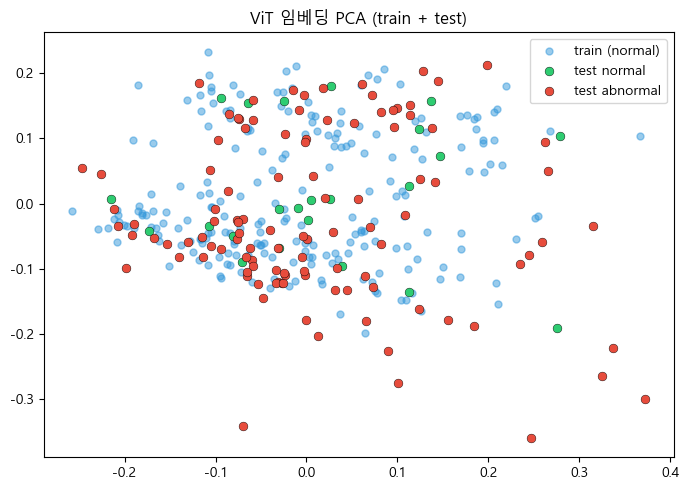

In [11]:
# ========== 임베딩 2D 시각화 (PCA) ==========
combined = torch.cat([emb_train, emb_test], dim=0).numpy()
combined_labels = np.concatenate([
    np.full(len(emb_train), -1),  # train = 정상(학습)
    y_test,
])

coords = PCA(n_components=2, random_state=42).fit_transform(combined)
n_train = len(emb_train)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coords[:n_train, 0], coords[:n_train, 1], c='#3498db', alpha=0.5,
           s=25, label='train (normal)')
mask_n = combined_labels[n_train:] == 0
mask_a = combined_labels[n_train:] == 1
ax.scatter(coords[n_train:][mask_n, 0], coords[n_train:][mask_n, 1],
           c='#2ecc71', s=40, label='test normal', edgecolors='k', linewidths=0.3)
ax.scatter(coords[n_train:][mask_a, 0], coords[n_train:][mask_a, 1],
           c='#e74c3c', s=40, label='test abnormal', edgecolors='k', linewidths=0.3)
ax.set_title('ViT 임베딩 PCA (train + test)')
ax.legend()
plt.tight_layout()
plt.show()

### 7. PoC ① — 정상 프로토타입 기반 이상 탐지

MVTec AD 표준 시나리오: **train에는 정상만** 존재한다고 가정합니다.

1. train 임베딩 평균 → 정상 **프로토타입**  
2. test 이미지와의 Cosine Similarity = **정상 점수**  
3. train 점수의 하위 `PERCENTILE`% 를 임계값으로 사용 → 미만이면 **불량** 예측

> 실무에서는 검증용 정상 샘플 또는 운영 로그로 임계값을 재조정합니다.

In [12]:
# ========== PoC 1: 프로토타입 + 임계값 ==========
train_scores = (emb_train @ normal_prototype).numpy()
THRESHOLD_PERCENTILE = 5  # train 정상 점수 하위 5% 미만 → abnormal

threshold = float(np.percentile(train_scores, THRESHOLD_PERCENTILE))
pred_proto = (sim_to_normal < threshold).astype(np.int64)

print(f'임계값 (cosine sim): {threshold:.4f}  (train p{THRESHOLD_PERCENTILE})')
print(f'Accuracy: {accuracy_score(y_test, pred_proto):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, -sim_to_normal):.4f}  (점수=−유사도)')
print(classification_report(y_test, pred_proto, target_names=['normal', 'abnormal']))

임계값 (cosine sim): 0.9526  (train p5)
Accuracy: 0.4091
ROC-AUC:  0.6426  (점수=−유사도)
              precision    recall  f1-score   support

      normal       0.22      0.91      0.35        23
    abnormal       0.94      0.30      0.46       109

    accuracy                           0.41       132
   macro avg       0.58      0.61      0.40       132
weighted avg       0.82      0.41      0.44       132



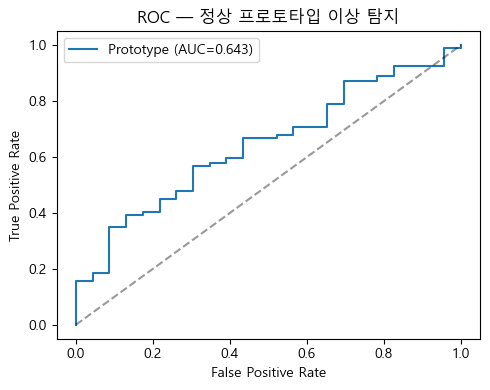

In [13]:
# ========== ROC 곡선 ==========
fpr, tpr, _ = roc_curve(y_test, -sim_to_normal)
auc = roc_auc_score(y_test, -sim_to_normal)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'Prototype (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — 정상 프로토타입 이상 탐지')
plt.legend()
plt.tight_layout()
plt.show()

### 8. PoC ② — k-NN 메모리 기반 이상 탐지

train **정상 임베딩만** 메모리로 저장하고, test 이미지와 가장 가까운 k개 이웃의
평균 Cosine Similarity가 낮을수록 **불량**으로 판정합니다. (라벨 누수 없음)

- Feature: ViT CLS 임베딩 (768-d)
- Memory: train 정상 219장
- k=5, 임계값은 train 이웃 점수 분포에서 산출

--- k-NN memory (cosine, k=5, train 정상만) ---
임계값 (kNN score): 0.9835
Accuracy: 0.6439
ROC-AUC:  0.7204
              precision    recall  f1-score   support

      normal       0.27      0.61      0.37        23
    abnormal       0.89      0.65      0.75       109

    accuracy                           0.64       132
   macro avg       0.58      0.63      0.56       132
weighted avg       0.78      0.64      0.69       132



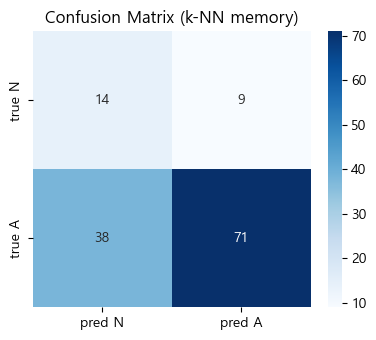

In [14]:
# ========== PoC 2: k-NN (train 정상 메모리만 사용) ==========
K_NEIGHBORS = 5

knn_mem = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='cosine')
knn_mem.fit(emb_train.numpy(), np.zeros(len(emb_train), dtype=np.int64))

# 이웃과의 평균 cosine similarity (높을수록 정상)
distances, _ = knn_mem.kneighbors(emb_test.numpy())
knn_scores = 1.0 - distances.mean(axis=1)

knn_train_scores = 1.0 - knn_mem.kneighbors(emb_train.numpy())[0].mean(axis=1)
knn_threshold = float(np.percentile(knn_train_scores, THRESHOLD_PERCENTILE))
pred_knn = (knn_scores < knn_threshold).astype(np.int64)

print('--- k-NN memory (cosine, k=5, train 정상만) ---')
print(f'임계값 (kNN score): {knn_threshold:.4f}')
print(f'Accuracy: {accuracy_score(y_test, pred_knn):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, -knn_scores):.4f}')
print(classification_report(y_test, pred_knn, target_names=['normal', 'abnormal']))

cm = confusion_matrix(y_test, pred_knn)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['pred N', 'pred A'],
            yticklabels=['true N', 'true A'])
ax.set_title('Confusion Matrix (k-NN memory)')
plt.tight_layout()
plt.show()

### 9. Pooling 방식 비교 (CLS vs Mean)

In [15]:
# ========== CLS vs Mean pooling AUC 비교 ==========
results = []
for strategy in ['cls', 'mean']:
    e_tr, _ = encode_hf_split(train_ds, strategy=strategy)
    e_te, y_te = encode_hf_split(test_ds, strategy=strategy)
    proto = F.normalize(e_tr.mean(dim=0, keepdim=True), p=2, dim=-1)[0]
    scores = (e_te @ proto).numpy()
    auc = roc_auc_score(y_te, -scores)
    results.append((strategy, auc))
    print(f'{strategy:5s} pooling — ROC-AUC (prototype): {auc:.4f}')

best = max(results, key=lambda x: x[1])[0]
print(f'\n권장 pooling (이 데이터 기준): {best}')

cls   pooling — ROC-AUC (prototype): 0.6426
mean  pooling — ROC-AUC (prototype): 0.6546

권장 pooling (이 데이터 기준): mean


### 10. (선택) Colab에서 단일 이미지 업로드 테스트

In [16]:
# ========== Colab 업로드 → 정상 유사도 점수 ==========
if IN_COLAB:
    from google.colab import files

    uploaded = files.upload()
    for name, data in uploaded.items():
        img = Image.open(io.BytesIO(data)).convert('RGB')
        emb = encode_pil_batch([img], strategy=POOLING)[0]
        score = float(emb @ normal_prototype)
        verdict = 'abnormal' if score < threshold else 'normal'
        print(f'{name}: cosine_sim={score:.4f} → 예측: {verdict}')
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'{verdict} (sim={score:.3f})')
        plt.show()
else:
    print('Colab에서만 업로드 셀이 동작합니다. 로컬에서는 PIL 경로로 encode_pil_batch를 호출하세요.')

Colab에서만 업로드 셀이 동작합니다. 로컬에서는 PIL 경로로 encode_pil_batch를 호출하세요.


### 11. 정리

| 단계 | 내용 |
|------|------|
| 데이터 | MVTec AD capsule — HF 자동 다운로드 |
| 표현 | ViT-Base CLS/Mean pooling → 768-d 임베딩 |
| 유사도 | 정상 프로토타입 Cosine Similarity, 행렬·분포 시각화 |
| PoC 1 | 비지도 이상 탐지 (train 정상만, percentile 임계값) |
| PoC 2 | k-NN 메모리 이상 탐지 (train 정상만, 라벨 누수 없음) |

**다음 단계 (실무 확장)**
- 결함 **유형별** 분류: `TheoM55/mvtec_all_objects_split` 의 `defect` 컬럼 활용
- 도메인 적응: 동일 ViT 백본 + Linear Probe / Fine-tuning
- Anomalib(PatchCore 등)와 임베딩 PoC 결과 비교

**참고**
- [MVTec AD Dataset](https://www.mvtec.com/company/research/datasets/mvtec-ad)
